In [1]:
# notebook to get an idea of the VEP annotations for exon filtered clinvar variants

In [1]:
import pprint
import pandas as pd
import pybedtools
import os
import requests
import time
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def vcf2df (file):
    pred_df = pd.read_csv(file, sep = '\t')
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
    
    df = pd.DataFrame({'chrom' : pred_df['chrom'],
                       'pos' : pred_df['pos'],
                       'id' : pred_df['id'],
                       'ref' : pred_df['ref'],
                       'alt' : pred_df['alt'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew})
    return df

In [3]:
# define function to return emVar status
def add_emvar (pred_df,
               cell_type,
               skew_cutoff):
    # make a list for emvar status
    emvar_list = []
    for skew in pred_df[f'{cell_type}_skew_pred'].tolist():
        if abs(skew) >= skew_cutoff:
            emvar_list.append(1)
        else:
            emvar_list.append(0)
    # add column to DF
    pred_df[f'{cell_type}_emvar'] = emvar_list
    return pred_df
# annotate emVars in predictions
def annotate_preds (df,
                    skew_thresh):
    # add k562 emVar status
    df = add_emvar(df,
                   'k562',
                   skew_thresh)
    # add hepg2 emVar status
    df = add_emvar(df,
                   'hepg2',
                   skew_thresh)
    # add sknsh emVar status
    df = add_emvar(df,
                   'sknsh',
                   skew_thresh)
    # add emVar any column
    df['emvar_any'] = [1 if [i,j,k].count(1) > 0 else 0 for i,j,k in zip(df['k562_emvar'],
                                                                         df['hepg2_emvar'],
                                                                         df['sknsh_emvar'])]
    return df

In [9]:
# open all updated predictions
os.chdir('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/processed_data/mpac_preds')
all_clinvar = pd.concat([vcf2df(i) for i in os.listdir() if i.endswith('.vcf')])
# break out id, clinsig
all_clinvar.loc[:, 'clinvar_id'] = [i.split(';')[0] for i in all_clinvar['id']]
# chrom:pos:ref:alt id
all_clinvar.loc[:, 'var_id'] = [i.split(';')[-1] for i in all_clinvar['id']]
# clinsig
all_clinvar.loc[:, 'clinsig'] = [i.split(';')[1] for i in all_clinvar['id']]
# label indels
all_clinvar.loc[:, 'indel'] = [1 if len(ref) > 1 or len(alt) > 1 else 0 for ref, alt in zip(all_clinvar['ref'], all_clinvar['alt'])]
# add emVars
all_clinvar = annotate_preds(all_clinvar, 0.5)
os.chdir('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/')

100%|██████████| 14128/14128 [00:00<00:00, 320494.16it/s]


100%|██████████| 18613/18613 [00:00<00:00, 326601.68it/s]


In [10]:
all_clinvar.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_alt_pred,sknsh_skew_pred,clinvar_id,var_id,clinsig,indel,k562_emvar,hepg2_emvar,sknsh_emvar,emvar_any
0,chr4,160676,4279098;None;chr4:160676:A:G,A,G,0.019091,0.017585,-0.001506,-0.078585,-0.056816,...,-0.074077,0.002044,4279098,chr4:160676:A:G,None,0,0,0,0,0
1,chr4,295423,4305190;None;chr4:295423:T:C,T,C,0.035983,0.065579,0.029596,0.247926,0.270079,...,-0.223992,0.011168,4305190,chr4:295423:T:C,None,0,0,0,0,0
2,chr4,344137,4305389;None;chr4:344137:G:A,G,A,0.094547,0.100146,0.005598,0.008075,0.002951,...,0.087903,-0.027435,4305389,chr4:344137:G:A,None,0,0,0,0,0
3,chr4,344194,4305390;None;chr4:344194:A:C,A,C,0.154514,0.150217,-0.004297,0.112597,0.114191,...,0.128940,-0.006250,4305390,chr4:344194:A:C,None,0,0,0,0,0
4,chr4,344311,4288640;None;chr4:344311:ATT:A,ATT,A,0.111253,0.039208,-0.072045,0.177554,0.107139,...,-0.254773,-0.059673,4288640,chr4:344311:ATT:A,None,1,0,0,0,0


In [11]:
# open the output from vep
vepOutput = pd.read_csv(
    '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/processed_data/all_exon_filtered_clinvar_preds_with_regulatory.tsv',
    sep = '\t',
    comment = '#',
    header = None
)

In [12]:
vepOutput.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4284673,chr15:21609065-21609067,-,ENSG00000285491,ENST00000638015,Transcript,upstream_gene_variant,-,YES,ENST00000332663,35,MODIFIER,-
1,4400926,chr15:21609144,A,ENSG00000285491,ENST00000638015,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000332663,-,MODIFIER,-
2,4400927,chr15:21609204,T,ENSG00000285491,ENST00000638015,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000332663,-,MODIFIER,-
3,4400928,chr15:21616692,T,-,-,-,intergenic_variant,-,-,ENST00000332663,-,MODIFIER,-
4,4400929,chr15:21616807,G,-,-,-,intergenic_variant,-,-,ENST00000332663,-,MODIFIER,-


In [15]:
# updated bed files contain transcript IDs, still need to break off a bit for matching
exonBED = pd.read_csv( # opening the splice containing bed file, shouldn't matter which for this
    'raw_data/archive2/gencode.v44.protein.coding.exons.splice.autosomes.v2.bed',
    sep = '\t',
    header = None
)
exonBED.loc[:, 'transcriptID'] = [i.split('_')[1]. split('.')[0] for i in exonBED[6]]

In [16]:
exonBED.head()

,0,1,2,3,4,5,6,transcriptID
0,chr1,65418,65439,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
1,chr1,65499,65579,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
2,chr1,69016,71585,OR4F5,0,+,ENSG00000186092.7_ENST00000641515.2_OR4F5,ENST00000641515
3,chr1,450739,451678,OR4F29,0,-,ENSG00000284733.2_ENST00000426406.4_OR4F29,ENST00000426406
4,chr1,685715,686654,OR4F16,0,-,ENSG00000284662.2_ENST00000332831.5_OR4F16,ENST00000332831


In [17]:
# okay let's see how how many features intersect with our exon calls
# filter with the transcript ids
# pad + reg
vepOutputCanonTranscripts = vepOutput[vepOutput[4].isin(list(exonBED['transcriptID'].unique()))]

In [18]:
len(vepOutputCanonTranscripts)

369784

In [19]:
# there are ppear to be some missing values once we filter for our transcripts- 12,028
canonMissing = list(set(all_clinvar['clinvar_id']) - set([str(i) for i in vepOutputCanonTranscripts[0]]))
len(set(all_clinvar['clinvar_id']) - set([str(i) for i in vepOutput[0]]))

0

In [20]:
missing_groupby = vepOutput[vepOutput[0].astype(str).isin(canonMissing)].groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [21]:
all_clinvar.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_alt_pred,sknsh_skew_pred,clinvar_id,var_id,clinsig,indel,k562_emvar,hepg2_emvar,sknsh_emvar,emvar_any
0,chr4,160676,4279098;None;chr4:160676:A:G,A,G,0.019091,0.017585,-0.001506,-0.078585,-0.056816,...,-0.074077,0.002044,4279098,chr4:160676:A:G,None,0,0,0,0,0
1,chr4,295423,4305190;None;chr4:295423:T:C,T,C,0.035983,0.065579,0.029596,0.247926,0.270079,...,-0.223992,0.011168,4305190,chr4:295423:T:C,None,0,0,0,0,0
2,chr4,344137,4305389;None;chr4:344137:G:A,G,A,0.094547,0.100146,0.005598,0.008075,0.002951,...,0.087903,-0.027435,4305389,chr4:344137:G:A,None,0,0,0,0,0
3,chr4,344194,4305390;None;chr4:344194:A:C,A,C,0.154514,0.150217,-0.004297,0.112597,0.114191,...,0.128940,-0.006250,4305390,chr4:344194:A:C,None,0,0,0,0,0
4,chr4,344311,4288640;None;chr4:344311:ATT:A,ATT,A,0.111253,0.039208,-0.072045,0.177554,0.107139,...,-0.254773,-0.059673,4288640,chr4:344311:ATT:A,None,1,0,0,0,0


In [22]:
len(vepOutputCanonTranscripts[0].unique())

361398

In [23]:
vepOutputCanonTranscripts.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
64,679847,chr15:22786298,G,ENSG00000170113,ENST00000337435,Transcript,upstream_gene_variant,-,YES,ENST00000337435,346,MODIFIER,-
73,1194677,chr15:22786362,C,ENSG00000170113,ENST00000337435,Transcript,upstream_gene_variant,-,YES,ENST00000337435,282,MODIFIER,-
82,1298008,chr15:22786447,-,ENSG00000170113,ENST00000337435,Transcript,upstream_gene_variant,-,YES,ENST00000337435,197,MODIFIER,-
90,315427,chr15:22786638,A,ENSG00000170113,ENST00000337435,Transcript,upstream_gene_variant,-,YES,ENST00000337435,6,MODIFIER,-
100,930279,chr15:22786843,A,ENSG00000170113,ENST00000337435,Transcript,intron_variant,-,YES,ENST00000337435,-,MODIFIER,-


In [24]:
Counter(vepOutputCanonTranscripts[6])

Counter({'intron_variant': 323797,
         'splice_region_variant,intron_variant': 24100,
         'upstream_gene_variant': 16543,
         'downstream_gene_variant': 4297,
         'splice_donor_5th_base_variant,intron_variant': 486,
         'splice_donor_region_variant,intron_variant': 234,
         'splice_polypyrimidine_tract_variant,intron_variant': 221,
         'splice_donor_variant,splice_donor_5th_base_variant,intron_variant': 73,
         'splice_donor_variant,splice_donor_5th_base_variant,coding_sequence_variant,intron_variant': 26,
         '5_prime_UTR_variant': 3,
         '3_prime_UTR_variant': 2,
         'splice_donor_variant,splice_donor_region_variant,intron_variant': 1,
         'splice_donor_variant,intron_variant': 1})

In [25]:
# group the calls by variant id
# pad + reg
vepOutputCanonTranscripts_grouped = vepOutputCanonTranscripts.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [26]:
vepOutputCanonTranscripts_grouped

,0,1,2,3,4,5,6,8,9,11
0,14,chr6:26093008,A,ENSG00000010704,ENST00000357618,Transcript,intron_variant,YES,ENST00000309234,MODIFIER
1,60,chr1:243305133,T,ENSG00000054282,ENST00000366541,Transcript,intron_variant,YES,ENST00000435549,MODIFIER
2,100,chr22:30615125,T,ENSG00000185339,ENST00000215838,Transcript,intron_variant,YES,ENST00000407817,MODIFIER
3,106,chr9:127785950,G,ENSG00000136807,ENST00000373264,Transcript,upstream_gene_variant,YES,ENST00000373264,MODIFIER
4,116,chr13:28659089,-,ENSG00000132963,ENST00000380842,Transcript,upstream_gene_variant,YES,ENST00000460403,MODIFIER
...,...,...,...,...,...,...,...,...,...,...
361393,4539962,chr3:184378347,T,ENSG00000090534,ENST00000647395,Transcript,upstream_gene_variant,YES,ENST00000647395,MODIFIER
361394,4540145,chr10:53822883,G,ENSG00000150275,ENST00000644397,Transcript,intron_variant,YES,ENST00000615043,MODIFIER
361395,4540289,chr10:87863611,T,"ENSG00000171862,ENSG00000227268","ENST00000371953,ENST00000445946",Transcript,upstream_gene_variant,YES,ENST00000700029,MODIFIER
361396,4540427,chr2:227269861,G,ENSG00000169031,ENST00000396578,Transcript,intron_variant,YES,ENST00000304990,MODIFIER


In [27]:
# add most severe consequence
VEP_SEVERITY = [
    "transcript_ablation",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "stop_gained",
    "frameshift_variant",
    "stop_lost",
    "start_lost",
    "transcript_amplification",
    "inframe_insertion",
    "inframe_deletion",
    "missense_variant",
    "protein_altering_variant",
    "splice_donor_5th_base_variant",
    "splice_region_variant",
    "splice_donor_region_variant",
    "splice_polypyrimidine_tract_variant",
    "incomplete_terminal_codon_variant",
    "start_retained_variant",
    "stop_retained_variant",
    "synonymous_variant",
    "coding_sequence_variant",
    "mature_miRNA_variant",
    "5_prime_UTR_variant",
    "3_prime_UTR_variant",
    "non_coding_transcript_exon_variant",
    "intron_variant",
    "NMD_transcript_variant",
    "non_coding_transcript_variant",
    "upstream_gene_variant",
    "downstream_gene_variant",
    "TFBS_ablation",
    "TFBS_amplification",
    "TF_binding_site_variant",
    "regulatory_region_ablation",
    "regulatory_region_amplification",
    "feature_elongation",
    "regulatory_region_variant",
    "feature_truncation",
    "intergenic_variant",
]

# Lower index = more severe
SEVERITY_RANK = {term: i for i, term in enumerate(VEP_SEVERITY)}

def most_severe(consequences):
    """Return the most severe consequence from a comma-separated string."""
    terms = [c.strip() for c in str(consequences).split(",")]
    ranked = sorted(terms, key=lambda t: SEVERITY_RANK.get(t, 999))
    return ranked[0]

In [28]:
# add most severe annotation
vepOutputCanonTranscripts_grouped['most_severe'] = vepOutputCanonTranscripts_grouped[6].apply(most_severe)
missing_groupby['most_severe'] = missing_groupby[6].apply(most_severe)

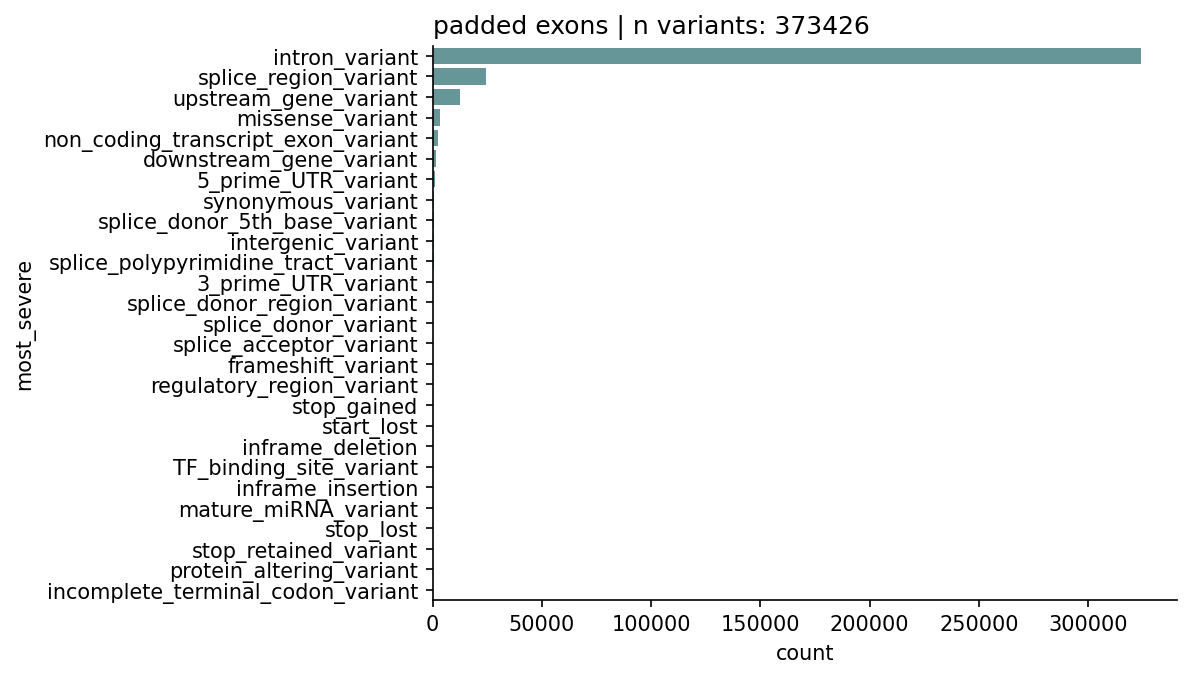

In [29]:
# plot the count of the most severe annotation for each
# pad + reg
plt.figure(dpi=150)
sns.countplot(
    pd.concat([vepOutputCanonTranscripts_grouped, missing_groupby])['most_severe'],
    order = pd.concat([vepOutputCanonTranscripts_grouped, missing_groupby])['most_severe'].value_counts().index,
    color = 'cadetblue'
)
plt.title(f'padded exons | n variants: {len(pd.concat([vepOutputCanonTranscripts_grouped, missing_groupby]))}', loc='left')
sns.despine()

In [34]:
Counter(pd.concat([vepOutputCanonTranscripts_grouped, missing_groupby])['most_severe'])

Counter({'intron_variant': 324294,
         'splice_region_variant': 24515,
         'upstream_gene_variant': 12706,
         'missense_variant': 3331,
         'non_coding_transcript_exon_variant': 2473,
         'downstream_gene_variant': 1349,
         '5_prime_UTR_variant': 916,
         'synonymous_variant': 683,
         'splice_donor_5th_base_variant': 541,
         'intergenic_variant': 525,
         'splice_polypyrimidine_tract_variant': 421,
         '3_prime_UTR_variant': 369,
         'splice_donor_region_variant': 353,
         'splice_donor_variant': 304,
         'splice_acceptor_variant': 151,
         'frameshift_variant': 138,
         'regulatory_region_variant': 120,
         'stop_gained': 98,
         'start_lost': 41,
         'inframe_deletion': 29,
         'TF_binding_site_variant': 26,
         'inframe_insertion': 17,
         'mature_miRNA_variant': 11,
         'stop_lost': 10,
         'stop_retained_variant': 3,
         'protein_altering_variant': 1,
  

In [47]:
# save the annotations and cosmic ids as txt file for adding to the analysis notebook
cat4save = pd.concat([vepOutputCanonTranscripts_grouped, missing_groupby])
# reformat for only clinvar id and most severe
df2save = pd.DataFrame({
    'clinvar_id' : cat4save[0].astype(str).tolist(),
    'most_severe' : cat4save['most_severe']
})
#df2save.to_csv('processed_data/clinvar_exon_filtered_vep_most_severe.txt', sep = '\t', index = False)

In [50]:
# make a dictionary
vep_dict = dict(zip(
    df2save['clinvar_id'].astype(str),
    df2save['most_severe']
))
# add vep annotatoin
all_clinvar.loc[:, 'vep_most_severe'] = [vep_dict.get(i) for i in all_clinvar['clinvar_id']]

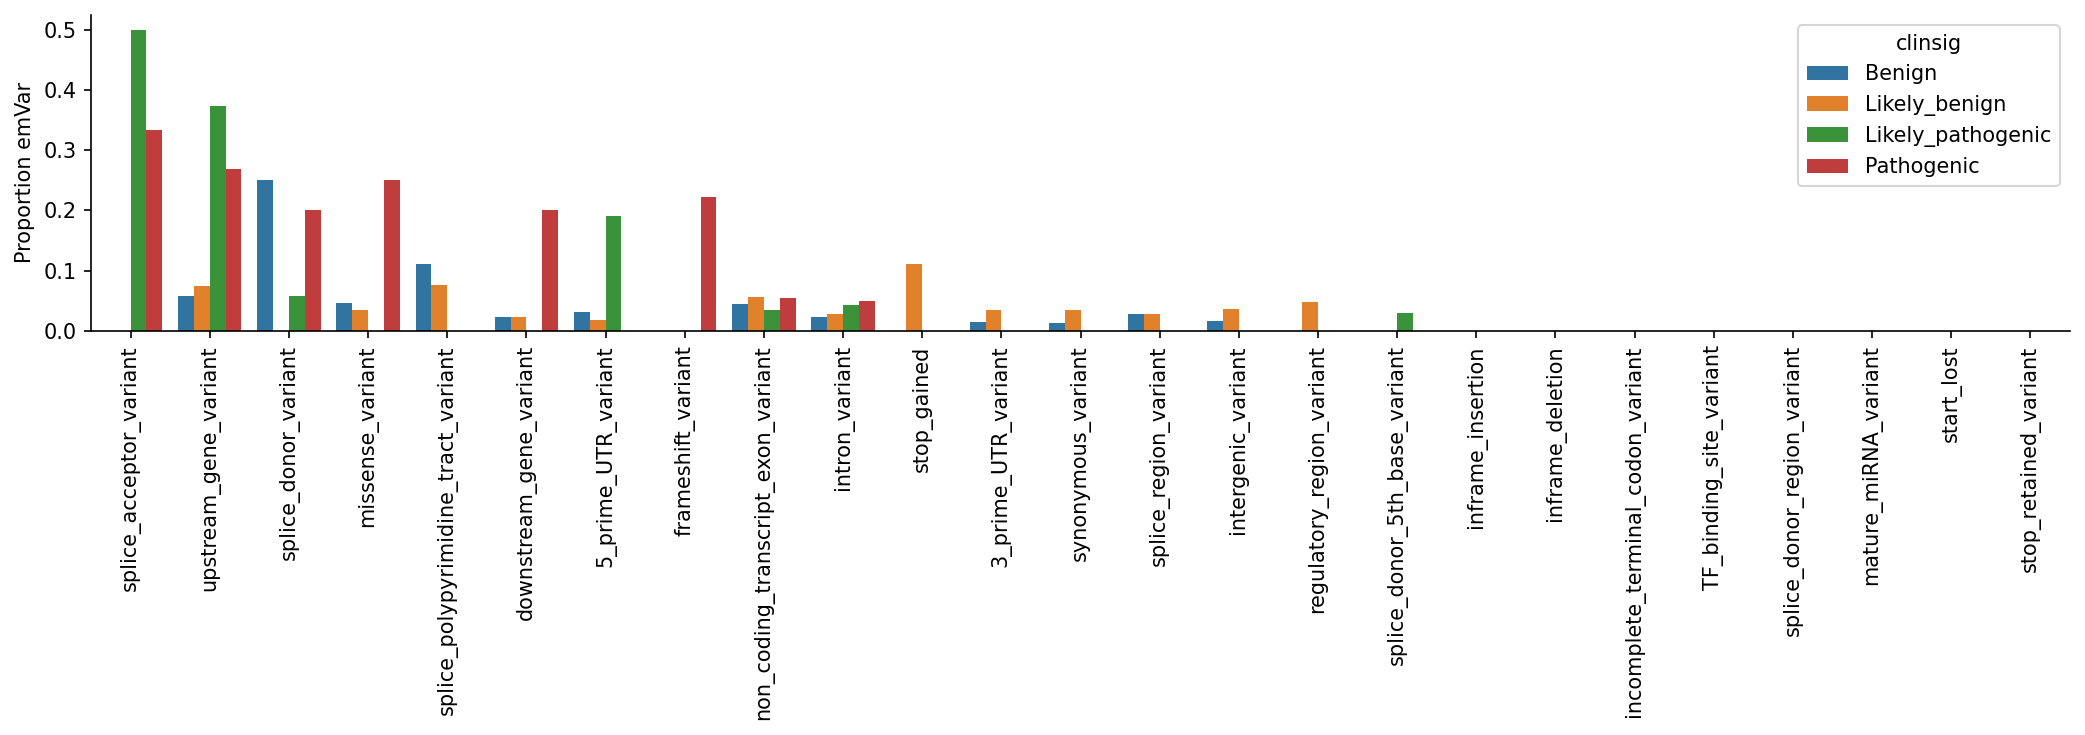

In [51]:
props = (
    all_clinvar[all_clinvar['clinsig'].isin(['Pathogenic', 'Likely_pathogenic', 'Benign', 'Likely_benign'])].groupby(['vep_most_severe', 'clinsig'])['emvar_any']
    .mean()
    .reset_index(name='emvar_proportion')
)

order = props.groupby('vep_most_severe')['emvar_proportion'].mean().sort_values(ascending=False).index

plt.figure(figsize=(14, 5), dpi=150)
sns.barplot(
    data=props,
    x='vep_most_severe',
    y='emvar_proportion',
    hue='clinsig',
    order=order
)
plt.xticks(rotation=90)
plt.ylabel('Proportion emVar')
plt.xlabel('')
sns.despine()
plt.tight_layout()